# Model Evaluation

## Objective

In [3]:
from pathlib import Path
import sys
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import RANDOM_SEED

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "GVLiD"
SPLIT_FILE = PROJECT_ROOT / "data" / "processed" / "dataset_split.csv"
RESULTS_DIR = PROJECT_ROOT / "results"

MODEL_PATH = RESULTS_DIR / "cnn_final.keras"
HISTORY_PATH = RESULTS_DIR / "training_history.pkl"

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Project root:", PROJECT_ROOT)
print("Model:", MODEL_PATH)
print("Split file:", SPLIT_FILE)

Project root: /home/chetan/Desktop/DL_Project/grapevine-disease-classification
Model: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_final.keras
Split file: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/data/processed/dataset_split.csv


## Load model and test data

In [4]:
model = tf.keras.models.load_model(MODEL_PATH)

split_df = pd.read_csv(SPLIT_FILE)

print("Model loaded successfully.")
print()
print(split_df["Split"].value_counts())

E0000 00:00:1789462605.075924   38470 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded successfully.

Split
Train         2492
Validation     510
Test           475
Name: count, dtype: int64


## Define Class Names and Construct Image Paths

In [5]:
class_names = ["Black Rot", "Esca", "Healthy", "Leaf Blight"]

print(class_names)

['Black Rot', 'Esca', 'Healthy', 'Leaf Blight']


In [6]:
split_df["image_path"] = split_df["image_filename"].apply(
    lambda x: str(RAW_DATA_DIR / x)
)

In [7]:
print(split_df[["image_filename", "image_path"]].head())

     image_filename                                         image_path
0  black rot001.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...
1  black rot002.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...
2  black rot003.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...
3  black rot004.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...
4  black rot005.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...


## Create the 3 splits and Verify the Test Images

In [8]:
train_df = split_df[split_df["Split"] == "Train"].copy()

val_df = split_df[split_df["Split"] == "Validation"].copy()

test_df = split_df[split_df["Split"] == "Test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2492
Validation: 510
Test: 475


In [9]:
missing = test_df[~test_df["image_path"].apply(lambda x: Path(x).exists())]

print("Missing test images:", len(missing))

if len(missing) > 0:
    print(missing[["image_filename", "image_path"]].head())

Missing test images: 475
      image_filename                                         image_path
8   black rot009.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...
14  black rot015.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...
15  black rot016.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...
24  black rot026.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...
26  black rot028.jpg  /home/chetan/Desktop/DL_Project/grapevine-dise...


## Create the Test Dataset

In [10]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [11]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [12]:
def make_dataset(df):

    paths = df["image_path"].astype(str).to_numpy()

    labels = df["label"].astype(np.int32).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [14]:
# Ensure the label column exists for the model pipeline
label_map = {label_name: idx for idx, label_name in enumerate(class_names)}

for df in (split_df, train_df, val_df, test_df):
    if "label" not in df.columns:
        df["label"] = df["Disease_Type"].map(label_map).astype(np.int32)

print(test_df[["Disease_Type", "label"]].head())

test_ds = make_dataset(test_df)
print("Test dataset created.")

print("Test dataset created.")

   Disease_Type  label
8     Black Rot      0
14    Black Rot      0
15    Black Rot      0
24    Black Rot      0
26    Black Rot      0
Test dataset created.
Test dataset created.


## Basic Model Evaluation

In [17]:
# Resolve test images robustly in case files are stored in nested folders or use different casing.
def resolve_image_path(filename: str) -> str:
    direct = RAW_DATA_DIR / filename
    if direct.exists():
        return str(direct)

    # Search recursively under the raw data directory.
    matches = list(RAW_DATA_DIR.rglob(filename))
    if matches:
        return str(matches[0])

    # Fallback for case-insensitive / formatting differences.
    matches = [
        str(p)
        for p in RAW_DATA_DIR.rglob("*")
        if p.is_file() and p.name.lower() == filename.lower()
    ]
    if matches:
        return matches[0]

    return str(direct)


# Rebuild the test image paths and drop any files that truly do not exist.
test_df = test_df.copy()
test_df["image_path"] = test_df["image_filename"].map(resolve_image_path)

missing_after_resolution = test_df[~test_df["image_path"].apply(lambda x: Path(x).exists())]
if len(missing_after_resolution) > 0:
    print(f"Warning: {len(missing_after_resolution)} test images are still missing after path resolution.")
    print(missing_after_resolution[["image_filename", "image_path"]].head())

test_df = test_df[test_df["image_path"].apply(lambda x: Path(x).exists())].copy()

if "label" not in test_df.columns:
    test_df["label"] = test_df["Disease_Type"].map(label_map).astype(np.int32)

test_ds = make_dataset(test_df)

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.4821 - loss: 2.9337
Test Loss: 2.9337
Test Accuracy: 0.4821
Test Loss: 2.9337
Test Accuracy: 0.4821


## Predictions

In [18]:
y_true = []
y_prob = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = np.argmax(y_prob, axis=1)

print("Predictions generated.")
print("Test samples:", len(y_true))

Predictions generated.
Test samples: 475


## Overall metrics

In [19]:
accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(y_true, y_pred, average="macro")

macro_recall = recall_score(y_true, y_pred, average="macro")

macro_f1 = f1_score(y_true, y_pred, average="macro")

weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")

Accuracy:        0.4821
Macro Precision: 0.4878
Macro Recall:    0.4490
Macro F1:        0.4576
Weighted F1:     0.4898


Pre-Class Evaluation

In [20]:
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)

print(report)

              precision    recall  f1-score   support

   Black Rot     0.8961    0.5750    0.7005       120
        Esca     0.6364    0.7903    0.7050       124
     Healthy     0.4189    0.4306    0.4247       144
 Leaf Blight     0.0000    0.0000    0.0000        87

    accuracy                         0.4821       475
   macro avg     0.4878    0.4490    0.4576       475
weighted avg     0.5195    0.4821    0.4898       475



In [21]:
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)

metrics_df = pd.DataFrame(report_dict).transpose()

metrics_df.to_csv(RESULTS_DIR / "classification_report.csv")

metrics_df

,precision,recall,f1-score,support
Black Rot,0.896104,0.575000,0.700508,120.000000
Esca,0.636364,0.790323,0.705036,124.000000
Healthy,0.418919,0.430556,0.424658,144.000000
Leaf Blight,0.000000,0.000000,0.000000,87.000000
accuracy,0.482105,0.482105,0.482105,0.482105
macro avg,0.487847,0.448970,0.457550,475.000000
weighted avg,0.519507,0.482105,0.489760,475.000000


## Confusion matrix

In [22]:
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)

metrics_df = pd.DataFrame(report_dict).transpose()

metrics_df.to_csv(RESULTS_DIR / "classification_report.csv")

metrics_df

,precision,recall,f1-score,support
Black Rot,0.896104,0.575000,0.700508,120.000000
Esca,0.636364,0.790323,0.705036,124.000000
Healthy,0.418919,0.430556,0.424658,144.000000
Leaf Blight,0.000000,0.000000,0.000000,87.000000
accuracy,0.482105,0.482105,0.482105,0.482105
macro avg,0.487847,0.448970,0.457550,475.000000
weighted avg,0.519507,0.482105,0.489760,475.000000


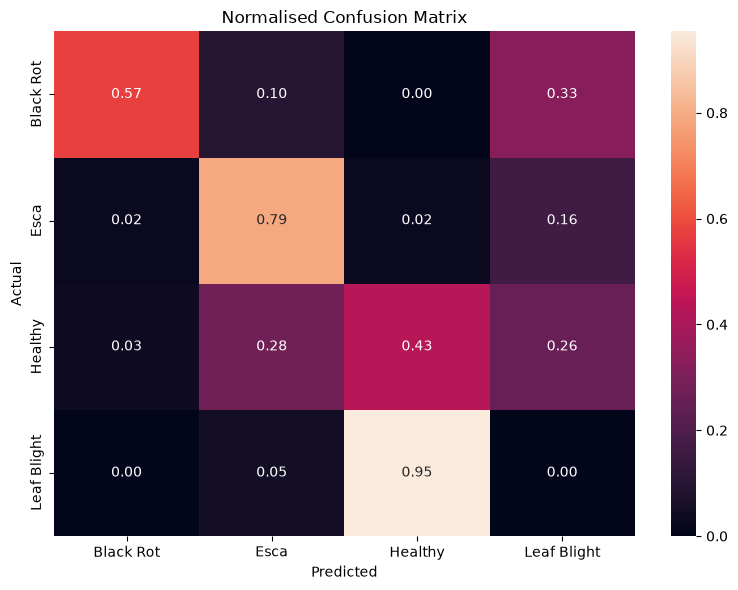

In [23]:
# Normalised Confusion Matrix
cm_normalized = confusion_matrix(y_true, y_pred, normalize="true")

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalised Confusion Matrix")

plt.tight_layout()
plt.show()

## Error Analysis

In [24]:
incorrect_indices = np.where(y_true != y_pred)[0]

print("Incorrect predictions:", len(incorrect_indices))

print("Error rate:", len(incorrect_indices) / len(y_true))

Incorrect predictions: 246
Error rate: 0.5178947368421053


In [25]:
errors_df = pd.DataFrame(
    {
        "image": test_df.iloc[incorrect_indices]["image_filename"].values,
        "actual": [class_names[i] for i in y_true[incorrect_indices]],
        "predicted": [class_names[i] for i in y_pred[incorrect_indices]],
        "confidence": np.max(y_prob[incorrect_indices], axis=1),
    }
)

errors_df = errors_df.sort_values("confidence", ascending=False)

errors_df.head(10)

,image,actual,predicted,confidence
243,healthy959.jpg,Leaf Blight,Healthy,0.999755
161,healthy361.jpg,Leaf Blight,Healthy,0.999579
190,healthy614.jpg,Leaf Blight,Healthy,0.999574
198,healthy651.jpg,Leaf Blight,Healthy,0.999559
220,healthy796.jpg,Leaf Blight,Healthy,0.999551
166,healthy388.jpg,Leaf Blight,Healthy,0.999531
194,healthy629.jpg,Leaf Blight,Healthy,0.999285
232,healthy896.jpg,Leaf Blight,Healthy,0.999165
244,healthy988.jpg,Leaf Blight,Healthy,0.999106
234,healthy911.jpg,Leaf Blight,Healthy,0.998816


## Most Common Misclassifcations

In [26]:
error_pairs = (
    errors_df.groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs

,actual,predicted,count
9,Leaf Blight,Healthy,83
6,Healthy,Esca,40
1,Black Rot,Leaf Blight,39
7,Healthy,Leaf Blight,37
4,Esca,Leaf Blight,20
0,Black Rot,Esca,12
5,Healthy,Black Rot,5
8,Leaf Blight,Esca,4
2,Esca,Black Rot,3
3,Esca,Healthy,3


## Incorrect Examples

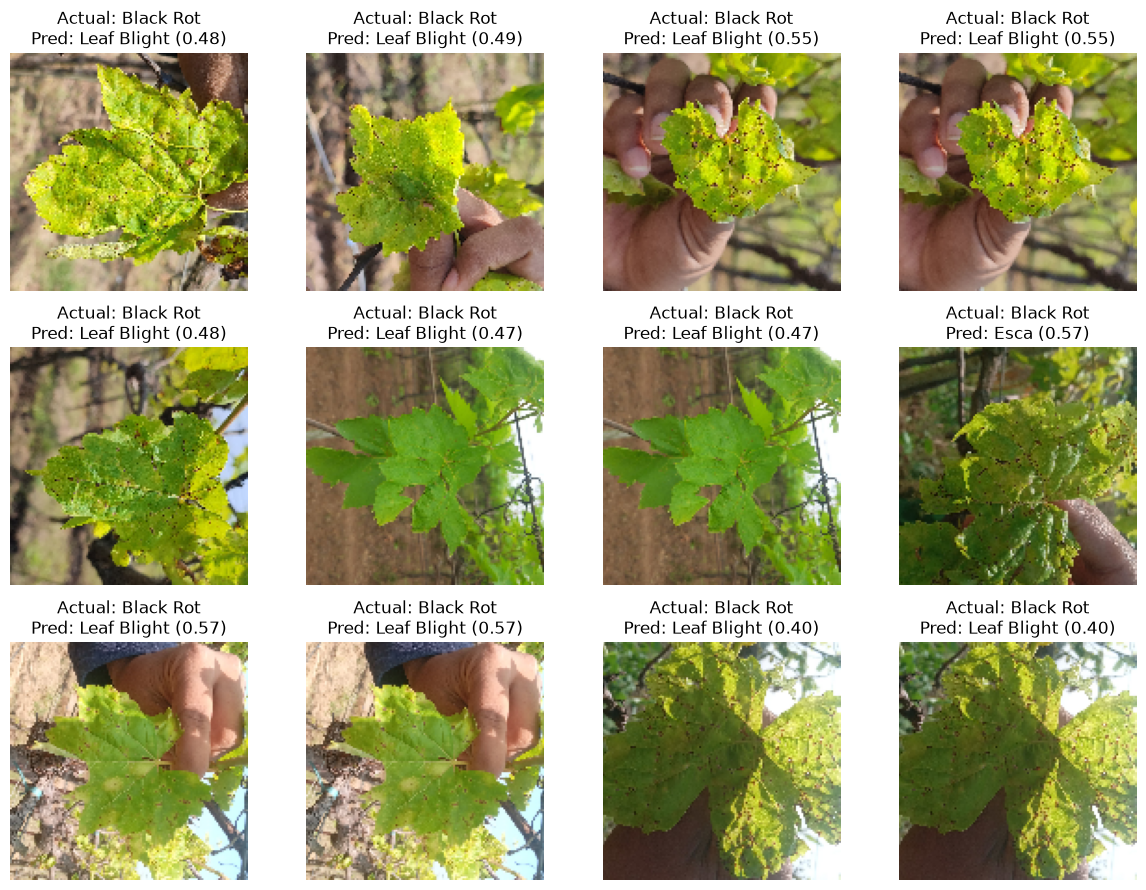

In [27]:
error_indices = incorrect_indices[:12]

plt.figure(figsize=(12, 9))

for i, idx in enumerate(error_indices):

    image = tf.keras.utils.load_img(
        test_df.iloc[idx]["image_path"], target_size=IMG_SIZE
    )

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]
    confidence = np.max(y_prob[idx])

    plt.title(f"Actual: {actual}\n" f"Pred: {predicted} ({confidence:.2f})")

    plt.axis("off")

plt.tight_layout()
plt.show()

## High-Confidence Errors

In [28]:
high_confidence_errors = errors_df[errors_df["confidence"] >= 0.80]

print("High-confidence errors:", len(high_confidence_errors))

high_confidence_errors.head(10)

High-confidence errors: 80


,image,actual,predicted,confidence
243,healthy959.jpg,Leaf Blight,Healthy,0.999755
161,healthy361.jpg,Leaf Blight,Healthy,0.999579
190,healthy614.jpg,Leaf Blight,Healthy,0.999574
198,healthy651.jpg,Leaf Blight,Healthy,0.999559
220,healthy796.jpg,Leaf Blight,Healthy,0.999551
166,healthy388.jpg,Leaf Blight,Healthy,0.999531
194,healthy629.jpg,Leaf Blight,Healthy,0.999285
232,healthy896.jpg,Leaf Blight,Healthy,0.999165
244,healthy988.jpg,Leaf Blight,Healthy,0.999106
234,healthy911.jpg,Leaf Blight,Healthy,0.998816


## Training/Validation Curves

In [29]:
with open(HISTORY_PATH, "rb") as f:
    history = pickle.load(f)

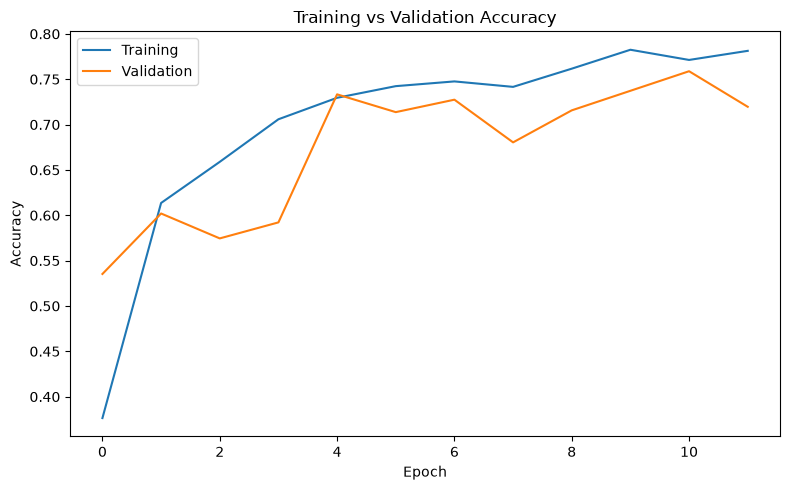

In [30]:
# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history["accuracy"], label="Training")

plt.plot(history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

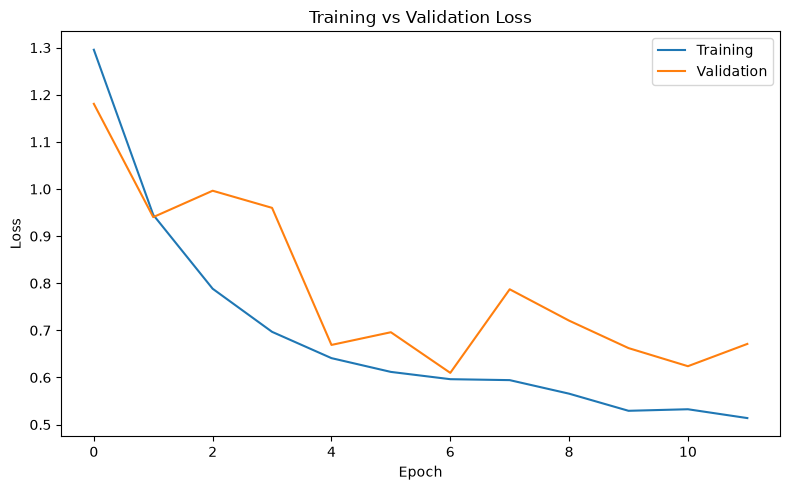

In [31]:
# Loss
plt.figure(figsize=(8, 5))

plt.plot(history["loss"], label="Training")

plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Final Results Table

In [32]:
final_results = pd.DataFrame(
    {
        "Metric": [
            "Test Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted F1",
        ],
        "Score": [accuracy, macro_precision, macro_recall, macro_f1, weighted_f1],
    }
)

final_results

,Metric,Score
0,Test Accuracy,0.482105
1,Macro Precision,0.487847
2,Macro Recall,0.448970
3,Macro F1,0.457550
4,Weighted F1,0.489760


In [39]:
final_results = pd.DataFrame(
    {
        "Metric": [
            "Test Accuracy",
            "Test Precision",
            "Test Recall",
            "Test F1-score",
        ],
        "Score": [
            accuracy,
            precision_score(y_true, y_pred, average="weighted"),
            recall_score(y_true, y_pred, average="weighted"),
            f1_score(y_true, y_pred, average="weighted"),
        ],
    }
)

final_results

,Metric,Score
0,Test Accuracy,0.482105
1,Test Precision,0.519507
2,Test Recall,0.482105
3,Test F1-score,0.489760


## Per-class recall / precision / F1

In [38]:
# Per-class evaluation metrics table

metrics_table = metrics_df.loc[class_names, ["precision", "recall", "f1-score"]].copy()



display(metrics_table.round(4))

,precision,recall,f1-score
Black Rot,0.8961,0.5750,0.7005
Esca,0.6364,0.7903,0.7050
Healthy,0.4189,0.4306,0.4247
Leaf Blight,0.0000,0.0000,0.0000


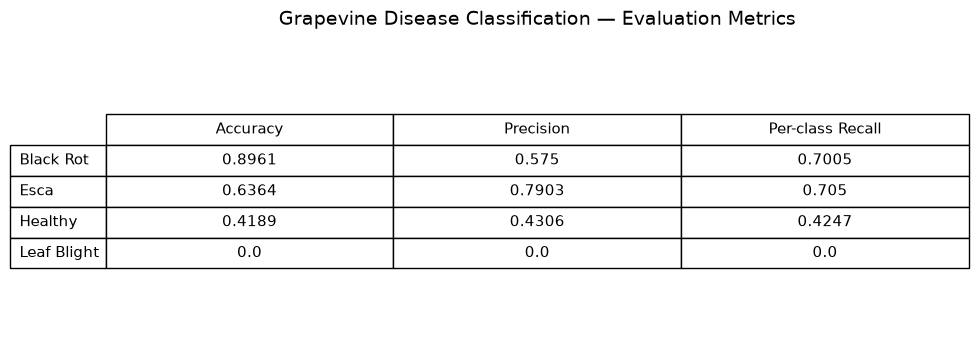

Saved to: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/figures/evaluation_metrics.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")

table = ax.table(
    cellText=metrics_table.round(4).values,
    rowLabels=metrics_table.index,
    colLabels=["Accuracy", "Precision", "Per-class Recall", "F1-score"],
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title("Grapevine Disease Classification — Evaluation Metrics", fontsize=14, pad=20)

plt.tight_layout()

figures_dir = RESULTS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

metrics_figure_path = figures_dir / "evaluation_metrics.png"
plt.savefig(metrics_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {metrics_figure_path}")

## Business interpretation

The model shows moderate ability to identify Black Rot and Esca, but its poor performance on Leaf Blight means it should currently be used only as decision support to prioritise human inspection, not as an automated diagnosis tool.

## Limitations

The overall accuracy of 48.2% and the 0.0% precision, recall and F1 for Leaf Blight indicate poor generalisation across all disease classes and make the model unreliable for deployment without further improvement.

## Proposed next pilots

Pilot with more balanced and diverse Leaf Blight images, additional field conditions, and targeted retraining to improve minority-class performance before testing the model with vineyard professionals.

## Final conclusions

The results demonstrate that a CNN can provide useful disease classification signals, particularly for Black Rot and Esca, but the current model is not sufficiently reliable for operational deployment. Further data collection, model improvement and human validation are required before using it in real vineyard decision-making.